# Imports and configurations

In [21]:
import datetime
from math import sqrt

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler


from scipy import stats



# Load data

In [22]:
# All the data files are stored in datasets folder in drive
# Download the data and change the paths accordingly
data = "CAR DETAILS FROM CAR DEKHO.csv"

In [23]:
df = pd.read_csv(data)

In [24]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


build a model to predict selling_price

In [26]:
# Convert categorical columns to integer representations

df['fuel_int'] = df['fuel'].map({'Petrol': 1, 'Diesel': 2})
df['seller_type_int'] = df['seller_type'].map({'Individual': 1, 'Dealer': 2})
df['transmission_int'] = df['transmission'].map({'Manual': 1, 'Automatic': 2})
df['owner_int'] = df['owner'].map({'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Fourth & Above Owner': 4, 'Test Drive Car': 5})

<Axes: >

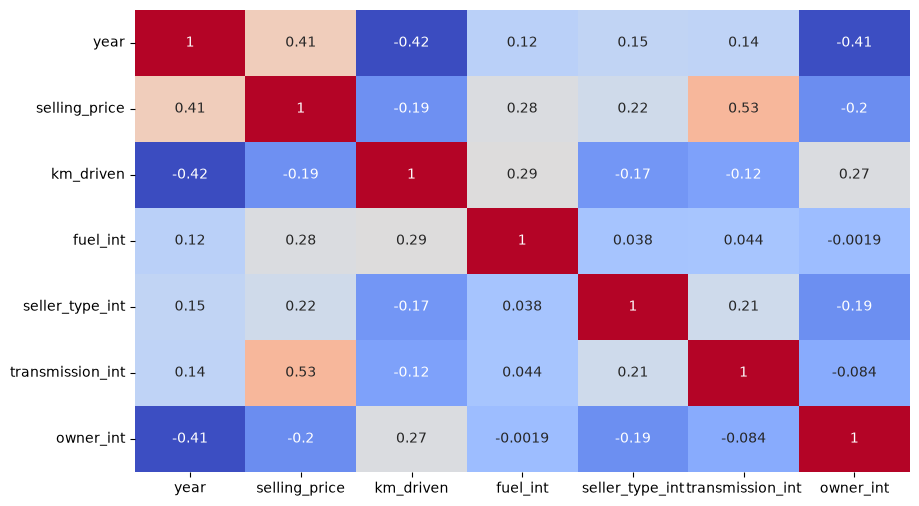

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', cbar=False)

In [ ]:
# Model training

model = LinearRegression()
X = df[['fuel_int', 'seller_type_int', 'transmission_int', 'owner_int']]
Y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.show()

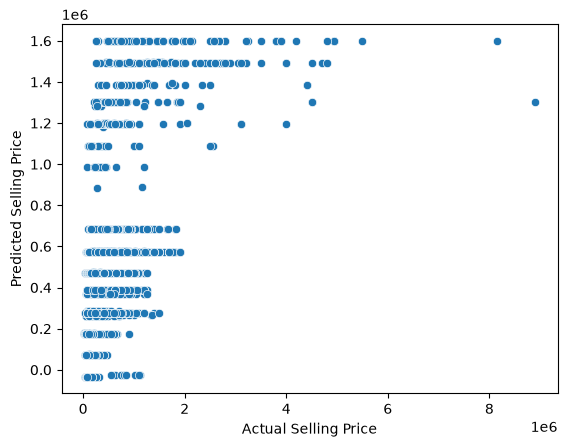

In [ ]:



valid_rows = X.notna().all(axis=1) & Y.notna()
X = X.loc[valid_rows]
Y = Y.loc[valid_rows]

model.fit(X, Y)
y_pred = model.predict(X)
sns.scatterplot(x=Y, y=y_pred)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.show()